In [1]:
print("Hello. This is a script that will plot roofline and where a kernel is on it.")

Hello. This is a script that will plot roofline and where a kernel is on it.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- CONFIGURATION: Theoretical Peaks (SXM5 Variants) ---
# Values approximate for A100 (40GB) and H100 (80GB)
gpu_configs = {
    'A100': {'peak_flops': 19500, 'peak_bw': 1555}, # FP32 GFLOPS, GB/s
    'H100': {'peak_flops': 67000, 'peak_bw': 3350}  # FP32 GFLOPS, TB/s
}

def plot_roofline(gpu_name, kernel_flops, kernel_bytes, kernel_time_ns):
    config = gpu_configs[gpu_name]
    peak_flops = config['peak_flops']
    peak_bw = config['peak_bw']
    
    # 1. Calculate Kernel Stats
    # AI = Total Flops / Total Bytes
    ai = kernel_flops / kernel_bytes
    # GFLOPS = (Total Flops / 1e9) / (Time in seconds)
    achieved_gflops = (kernel_flops / 1e9) / (kernel_time_ns / 1e9)
    
    # 2. Setup Roofline Data
    ai_range = np.logspace(-2, 2, 100)
    roofline = np.minimum(peak_flops, peak_bw * ai_range)
    
    # 3. Plotting
    plt.figure(figsize=(10, 6))
    plt.loglog(ai_range, roofline, label=f'{gpu_name} Roofline', color='black', lw=2)
    plt.scatter(ai, achieved_gflops, color='red', marker='x', s=100, label='Your Kernel')
    
    # Efficiency calculation
    theoretical_max = min(peak_flops, peak_bw * ai)
    efficiency = (achieved_gflops / theoretical_max) * 100
    
    plt.title(f'Roofline Analysis: {gpu_name}\nEfficiency: {efficiency:.2f}% of Theoretical Max')
    plt.xlabel('Arithmetic Intensity (FLOP/Byte)')
    plt.ylabel('Performance (GFLOP/s)')
    plt.grid(True, which="both", ls="-", alpha=0.5)
    plt.legend()
    plt.show()

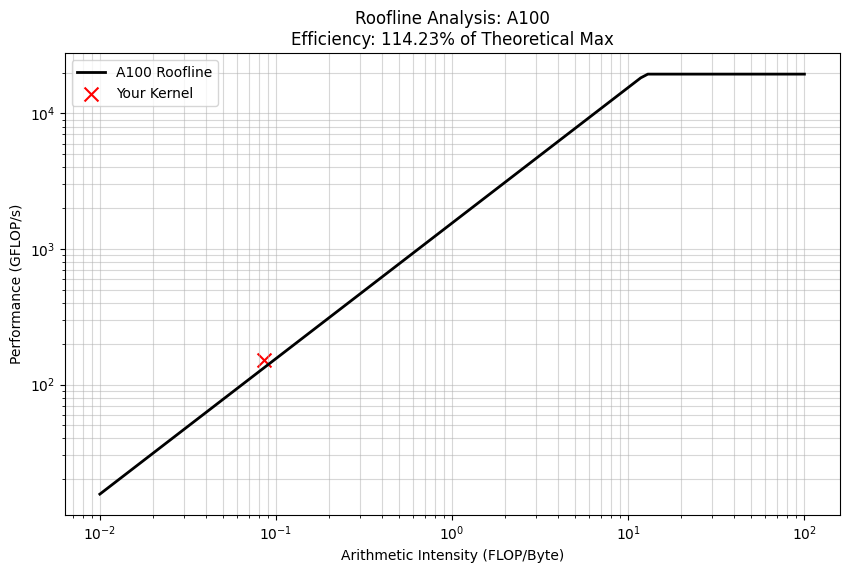

In [6]:
## A100 VECTOR ADD

plot_roofline(
    gpu_name='A100', 
    kernel_flops=33554432, 
    kernel_bytes=394.88e6, 
    kernel_time_ns=222300
)

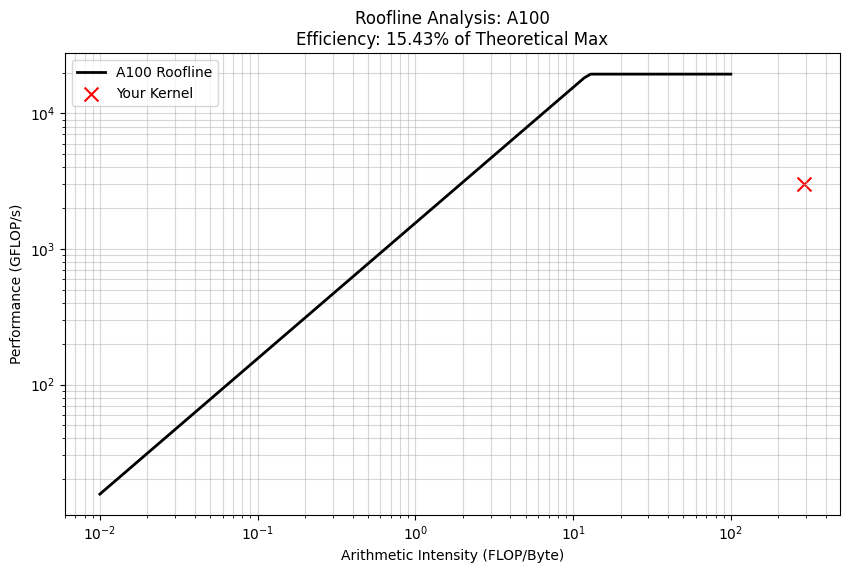

In [8]:
## A100 NATIVE GEMM
plot_roofline(
    gpu_name='A100', 
    kernel_flops=17179869184, 
    kernel_bytes=58.68e6, 
    kernel_time_ns=5710000
)